# 5-Fold Cross-Validation: Quantile TFT
Temporal 5-fold CV with all metrics: RMSE, Competition Score, Calibration, Coverage, Pinball Loss, Multi-Horizon Analysis.

In [1]:
import os, sys, random, warnings, time, logging, gc
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()} - {torch.cuda.get_device_name(0) if torch.cuda.is_available() else ''}")

OUTPUT_DIR = Path("checkpoints_07_kfold")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
LOG_FILE = OUTPUT_DIR / f"kfold_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    handlers=[logging.FileHandler(LOG_FILE, encoding="utf-8"), logging.StreamHandler()],
    force=True
)
log = logging.getLogger(__name__)
log.info("Started 5-Fold CV Pipeline")

2026-04-13 17:03:28 | Started 5-Fold CV Pipeline


PyTorch: 2.6.0+cu124
CUDA: True - NVIDIA RTX A1000


## Configuration

In [3]:
SEQ_LEN        = 4
BATCH_SIZE     = 1024
MAX_TRAIN_SEQ  = None
MAX_VAL_SEQ    = 500_000
TOP_K_FEATURES = 30
HIDDEN_DIM     = 48
NUM_HEADS      = 8
DROPOUT        = 0.3
EMBED_DIM      = 8
LR             = 1e-3
WEIGHT_DECAY   = 1e-3
EPOCHS         = 40
QUANTILES      = [0.1, 0.5, 0.9]
CLIP_NORM      = 1.0
K_FOLDS        = 5

## Data Loading

In [6]:
log.info("Loading Data...")
DATA_DIR   = Path(r"D:\Gautam\SEM_2\DL")
TRAIN_PATH = DATA_DIR / "TFT" / "data" / "train.parquet"
#TEST_PATH  = DATA_DIR / "TFT" / "data" / "test.parquet"

train_pl = pl.scan_parquet(str(TRAIN_PATH)).collect()
train_pd = train_pl.to_pandas()
del train_pl

TARGET_COL  = "y_target"
WEIGHT_COL  = "weight"
TIME_COL    = "ts_index"
ID_COL      = "id"
HORIZON_COL = "horizon"
GROUP_COLS  = [c for c in ["code", "sub_code", "sub_category"] if c in train_pd.columns]

train_pd = train_pd.sort_values(GROUP_COLS + [TIME_COL])
train_pd[WEIGHT_COL] = train_pd[WEIGHT_COL].clip(lower=0).values

feature_cols_all = [c for c in train_pd.columns if c not in [TARGET_COL, WEIGHT_COL, ID_COL]]
numeric_cols_all = [c for c in feature_cols_all if pd.api.types.is_numeric_dtype(train_pd[c])]
cat_feature_cols = [c for c in feature_cols_all if c not in numeric_cols_all]

log.info(f"Data Shape: {train_pd.shape}")

2026-04-13 17:05:12 | Loading Data...
2026-04-13 17:05:15 | Data Shape: (5337414, 94)


## Feature Selection & Categorical Encoding

In [7]:
log.info(f"Selecting Top {TOP_K_FEATURES} Features...")

def weighted_abs_corr(x, y, w):
    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(w)
    if mask.sum() < 10: return 0.0
    x, y, w = x[mask], y[mask], w[mask]
    w_sum = w.sum()
    if w_sum <= 0: return 0.0
    xm = np.sum(w * x) / w_sum
    ym = np.sum(w * y) / w_sum
    cov = np.sum(w * (x - xm) * (y - ym)) / w_sum
    xv = np.sum(w * np.square(x - xm)) / w_sum
    yv = np.sum(w * np.square(y - ym)) / w_sum
    if xv <= 0 or yv <= 0: return 0.0
    return float(abs(cov / np.sqrt(xv * yv)))

sample_df = train_pd.sort_values(TIME_COL).tail(min(len(train_pd), 800_000))
y_s, w_s = sample_df[TARGET_COL].values, sample_df[WEIGHT_COL].values
scores = [(col, weighted_abs_corr(sample_df[col].values, y_s, w_s)) for col in numeric_cols_all]
scores.sort(key=lambda x: x[1], reverse=True)
top_numeric_cols = [x[0] for x in scores[:TOP_K_FEATURES]]
log.info(f"Selected: {top_numeric_cols}")

cat_maps, cat_vocab_sizes = {}, {}
for c in cat_feature_cols:
    vals = train_pd[c].astype(str).fillna("__NA__")
    vocab = {v: i + 1 for i, v in enumerate(sorted(vals.unique()))}
    cat_maps[c], cat_vocab_sizes[c] = vocab, len(vocab) + 1
    train_pd[c] = train_pd[c].astype(str).map(vocab).fillna(0).astype(np.int64)

model_feature_cols = top_numeric_cols + cat_feature_cols
static_feature_names = [c for c in cat_feature_cols if c in model_feature_cols]
known_future_names = [c for c in [TIME_COL, HORIZON_COL] if c in model_feature_cols and c not in static_feature_names]
observed_feature_names = [c for c in model_feature_cols if c not in static_feature_names]

static_idx = [model_feature_cols.index(c) for c in static_feature_names]
known_future_idx = [model_feature_cols.index(c) for c in known_future_names]
observed_idx = [model_feature_cols.index(c) for c in observed_feature_names]
cat_indices_in_fv = [model_feature_cols.index(c) for c in cat_feature_cols]
cat_vsizes = [cat_vocab_sizes[c] for c in cat_feature_cols]

2026-04-13 17:05:29 | Selecting Top 30 Features...
2026-04-13 17:05:33 | Selected: ['feature_bn', 'feature_u', 'feature_ca', 'feature_am', 'feature_cd', 'feature_bo', 'feature_v', 'feature_an', 'feature_ap', 'feature_bm', 'feature_cb', 'feature_al', 'feature_i', 'feature_bz', 'feature_ag', 'feature_be', 'feature_r', 'feature_ae', 'feature_ah', 'horizon', 'feature_cc', 'feature_s', 'feature_bd', 'feature_h', 'feature_ai', 'feature_ay', 'feature_by', 'feature_k', 'feature_bg', 'feature_ac']


## Model Architecture & Helper Functions

In [8]:
class GLU(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc, self.gate = nn.Linear(dim, dim), nn.Linear(dim, dim)
    def forward(self, x):
        return self.fc(x) * torch.sigmoid(self.gate(x))

class GRN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim=None, dropout=0.1, context_dim=None):
        super().__init__()
        out_dim = out_dim or in_dim
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.context_fc = nn.Linear(context_dim, hidden_dim, bias=False) if context_dim else None
        self.elu, self.fc2 = nn.ELU(), nn.Linear(hidden_dim, out_dim)
        self.dropout, self.glu = nn.Dropout(dropout), GLU(out_dim)
        self.skip = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()
        self.norm = nn.LayerNorm(out_dim)
    def forward(self, x, context=None):
        h = self.fc1(x)
        if self.context_fc is not None and context is not None:
            while context.dim() < h.dim(): context = context.unsqueeze(1)
            h = h + self.context_fc(context)
        return self.norm(self.glu(self.fc2(self.dropout(self.elu(h)))) + self.skip(x))

class VariableSelectionNetwork(nn.Module):
    def __init__(self, num_vars, hidden_dim, dropout=0.1, context_dim=None):
        super().__init__()
        self.num_vars = num_vars
        self.var_grns = nn.ModuleList([GRN(1, hidden_dim, hidden_dim, dropout) for _ in range(num_vars)])
        self.weight_grn = GRN(num_vars, hidden_dim, num_vars, dropout, context_dim=context_dim)
    def forward(self, x, context=None):
        is_temporal = x.dim() == 3
        if self.num_vars == 0:
            return (torch.zeros(x.size(0), x.size(1), 1, device=x.device) if is_temporal
                    else torch.zeros(x.size(0), 1, device=x.device)), None
        if is_temporal:
            transformed = torch.stack([self.var_grns[i](x[..., i:i+1]) for i in range(self.num_vars)], dim=-2)
            weights = torch.softmax(self.weight_grn(x, context), dim=-1).unsqueeze(-1)
            return (transformed * weights).sum(dim=-2), weights.squeeze(-1)
        else:
            transformed = torch.stack([self.var_grns[i](x[:, i:i+1]) for i in range(self.num_vars)], dim=1)
            weights = torch.softmax(self.weight_grn(x, context), dim=-1).unsqueeze(-1)
            return (transformed * weights).sum(dim=1), weights.squeeze(-1)

class TFTv2(nn.Module):
    def __init__(self, static_idx, known_future_idx, observed_idx, cat_feature_indices,
                 cat_vocab_sizes_list, hidden_dim=32, num_heads=2, dropout=0.35, embed_dim=8, n_quantiles=3):
        super().__init__()
        self.cat_feature_indices, self.hidden_dim = cat_feature_indices, hidden_dim
        self.cat_embeddings = nn.ModuleList([nn.Embedding(vs, embed_dim, padding_idx=0) for vs in cat_vocab_sizes_list])
        n_cont = len([i for i in observed_idx if i not in cat_feature_indices])
        self.static_fc = nn.Linear(len(cat_feature_indices) * embed_dim, hidden_dim)
        self.static_context_grn = GRN(hidden_dim, hidden_dim, hidden_dim, dropout)
        self.observed_idx, self.known_future_idx = observed_idx, known_future_idx
        self.observed_vsn = VariableSelectionNetwork(n_cont, hidden_dim, dropout, context_dim=hidden_dim)
        self.known_vsn = VariableSelectionNetwork(len(known_future_idx), hidden_dim, dropout, context_dim=hidden_dim) if len(known_future_idx) > 0 else None
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.post_lstm_grn = GRN(hidden_dim, hidden_dim, hidden_dim, dropout)
        self.static_enrichment = GRN(hidden_dim, hidden_dim, hidden_dim, dropout, context_dim=hidden_dim)
        self.attn = nn.MultiheadAttention(hidden_dim, num_heads=num_heads, dropout=dropout, batch_first=True)
        self.post_attn_grn = GRN(hidden_dim, hidden_dim, hidden_dim, dropout)
        self.position_grn = GRN(hidden_dim, hidden_dim, hidden_dim, dropout)
        self.output_head = nn.Linear(hidden_dim, n_quantiles)
    def forward(self, x):
        b, t, _ = x.shape
        if self.cat_feature_indices:
            cat_embeds = [self.cat_embeddings[k](x[:, 0, idx].long().clamp(min=0)) for k, idx in enumerate(self.cat_feature_indices)]
            static_ctx = torch.relu(self.static_fc(torch.cat(cat_embeds, dim=-1)))
        else:
            static_ctx = torch.zeros(b, self.hidden_dim, device=x.device)
        static_ctx = self.static_context_grn(static_ctx)
        cont_idx = [i for i in self.observed_idx if i not in self.cat_feature_indices]
        obs_repr, _ = self.observed_vsn(x[:, :, cont_idx], context=static_ctx)
        if self.known_vsn:
            known_repr, _ = self.known_vsn(x[:, :, self.known_future_idx], context=static_ctx)
            temporal_in = obs_repr + known_repr
        else:
            temporal_in = obs_repr
        lstm_out, _ = self.lstm(temporal_in)
        temporal = self.post_lstm_grn(lstm_out)
        temporal = self.static_enrichment(temporal, context=static_ctx)
        mask = torch.triu(torch.ones(t, t, device=x.device), diagonal=1).bool()
        attn_out, _ = self.attn(temporal, temporal, temporal, attn_mask=mask, need_weights=False)
        temporal = self.post_attn_grn(temporal + attn_out)
        temporal = self.position_grn(temporal)
        return self.output_head(temporal[:, -1, :])

def quantile_loss(y_true, y_pred, w, quantiles=[0.1, 0.5, 0.9]):
    errors = y_true.unsqueeze(-1) - y_pred
    q = torch.tensor(quantiles, device=y_pred.device)
    return torch.mean(w.unsqueeze(-1) * torch.max((q - 1) * errors, q * errors))

def make_sequences(df, seq_len, feature_cols, target_col, weight_col=None,
                   group_cols=None, time_col="ts_index", max_samples=None):
    X, y, w = [], [], []
    if group_cols and all(c in df.columns for c in group_cols):
        iterable = (g.sort_values(time_col) for _, g in df.groupby(group_cols, sort=False))
    else:
        iterable = [df.sort_values(time_col)]
    count = 0
    for gdf in iterable:
        vals = gdf[feature_cols].values.astype(np.float32)
        yt = gdf[target_col].values.astype(np.float32)
        wt = gdf[weight_col].values.astype(np.float32) if weight_col else np.ones(len(gdf), dtype=np.float32)
        if len(gdf) <= seq_len: continue
        for i in range(seq_len, len(gdf)):
            if max_samples is None or count < max_samples:
                X.append(vals[i-seq_len:i]); y.append(yt[i]); w.append(wt[i])
            else:
                j = random.randint(0, count)
                if j < max_samples: X[j]=vals[i-seq_len:i]; y[j]=yt[i]; w[j]=wt[i]
            count += 1
    return np.asarray(X), np.asarray(y), np.asarray(w)

def _clip01(x): return float(np.minimum(np.maximum(x, 0.0), 1.0))

def weighted_rmse_score(y_target, y_pred, w):
    denom = np.sum(w * y_target**2)
    if denom == 0: return 0.0
    ratio = np.sum(w * (y_target - y_pred)**2) / denom
    return float(np.sqrt(1.0 - _clip01(ratio)))

def pinball_np(y, q_pred, tau):
    e = y - q_pred
    return np.mean(np.maximum(tau * e, (tau - 1) * e))

def create_model():
    return TFTv2(static_idx, known_future_idx, observed_idx, cat_indices_in_fv, cat_vsizes,
                 HIDDEN_DIM, NUM_HEADS, DROPOUT, EMBED_DIM, len(QUANTILES)).to(DEVICE)

log.info("Model & helpers defined.")

2026-04-13 17:05:59 | Model & helpers defined.


## 5-Fold Temporal Cross-Validation

In [9]:
log.info("=" * 60)
log.info("STARTING 5-FOLD TEMPORAL CROSS-VALIDATION")
log.info("=" * 60)

unique_times = np.sort(train_pd[TIME_COL].unique())
fold_size = len(unique_times) // K_FOLDS
log.info(f"Unique timestamps: {len(unique_times)} | Per fold: ~{fold_size}")

all_fold_results = []

for fold in range(K_FOLDS):
    fold_start = time.time()
    log.info(f"\n{'='*60}\nFOLD {fold+1}/{K_FOLDS}\n{'='*60}")

    # Temporal split
    vs = fold * fold_size
    ve = (fold+1)*fold_size if fold < K_FOLDS-1 else len(unique_times)
    val_times = set(unique_times[vs:ve])
    tr_df = train_pd.loc[~train_pd[TIME_COL].isin(val_times)].copy()
    vl_df = train_pd.loc[train_pd[TIME_COL].isin(val_times)].copy()
    log.info(f"Train: {len(tr_df):,} | Val: {len(vl_df):,}")

    # Per-fold impute & scale
    for c in top_numeric_cols:
        m = tr_df[c].median()
        tr_df[c] = tr_df[c].fillna(m)
        vl_df[c] = vl_df[c].fillna(m)
    scaler = StandardScaler()
    tr_df[top_numeric_cols] = scaler.fit_transform(tr_df[top_numeric_cols])
    vl_df[top_numeric_cols] = scaler.transform(vl_df[top_numeric_cols])

    # Build sequences
    X_tr, y_tr, w_tr = make_sequences(tr_df, SEQ_LEN, model_feature_cols, TARGET_COL, WEIGHT_COL, GROUP_COLS, TIME_COL, MAX_TRAIN_SEQ)
    X_vl, y_vl, w_vl = make_sequences(vl_df, SEQ_LEN, model_feature_cols, TARGET_COL, WEIGHT_COL, GROUP_COLS, TIME_COL, MAX_VAL_SEQ)
    log.info(f"X_train: {X_tr.shape} | X_val: {X_vl.shape}")
    if len(X_vl) == 0:
        log.warning("No val sequences, skipping."); continue

    train_loader = DataLoader(TensorDataset(torch.tensor(X_tr, dtype=torch.float32), torch.tensor(y_tr, dtype=torch.float32), torch.tensor(w_tr, dtype=torch.float32)),
                              batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(TensorDataset(torch.tensor(X_vl, dtype=torch.float32), torch.tensor(y_vl, dtype=torch.float32), torch.tensor(w_vl, dtype=torch.float32)),
                            batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    del X_tr; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    # Train
    torch.manual_seed(SEED + fold)
    model = create_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    WE = 3
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer,
        lambda ep: (ep+1)/WE if ep < WE else 0.5*(1+np.cos(np.pi*(ep-WE)/max(1,EPOCHS-WE))))

    train_losses, val_losses, val_rmses = [], [], []
    best_vl = float('inf')
    for epoch in range(1, EPOCHS+1):
        t0 = time.time()
        model.train(); bl = []
        for xb, yb, wb in train_loader:
            xb, yb, wb = xb.to(DEVICE), yb.to(DEVICE), wb.to(DEVICE)
            optimizer.zero_grad()
            loss = quantile_loss(yb, model(xb), wb, QUANTILES)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
            optimizer.step(); bl.append(loss.item())
        scheduler.step()
        tl = np.mean(bl); train_losses.append(tl)

        model.eval(); vbl = []; se, ws = 0.0, 0.0
        with torch.no_grad():
            for xb, yb, wb in val_loader:
                xb, yb, wb = xb.to(DEVICE), yb.to(DEVICE), wb.to(DEVICE)
                pred = model(xb)
                vbl.append(quantile_loss(yb, pred, wb, QUANTILES).item())
                p50 = pred[:, 1]
                se += (wb * (yb - p50)**2).sum().item()
                ws += wb.sum().item()
        vl = np.mean(vbl); rmse = np.sqrt(se/max(ws, 1e-12))
        val_losses.append(vl); val_rmses.append(rmse)
        tag = " *" if vl < best_vl else ""
        best_vl = min(best_vl, vl)
        log.info(f"  Ep {epoch:02d} | Tr: {tl:.4f} | Val: {vl:.4f} | RMSE: {rmse:.6f} | {time.time()-t0:.1f}s{tag}")

    # Evaluate final model
    model.eval()
    ap10, ap50, ap90 = [], [], []
    with torch.no_grad():
        for xb, yb, wb in val_loader:
            pred = model(xb.to(DEVICE))
            ap10.append(pred[:,0].cpu().numpy())
            ap50.append(pred[:,1].cpu().numpy())
            ap90.append(pred[:,2].cpu().numpy())
    p10, p50p, p90 = np.concatenate(ap10), np.concatenate(ap50), np.concatenate(ap90)

    # Metrics
    raw_sc = weighted_rmse_score(y_vl, p50p, w_vl)
    denom = np.sum(w_vl * p50p**2)
    opt_s = np.sum(w_vl * y_vl * p50p) / max(denom, 1e-12) if denom > 0 else 0
    opt_sc = weighted_rmse_score(y_vl, p50p * opt_s, w_vl)

    wn = w_vl / max(w_vl.sum(), 1e-12)
    in_iv = (y_vl >= p10) & (y_vl <= p90)

    fold_result = {
        'fold': fold+1, 'train_losses': train_losses, 'val_losses': val_losses, 'val_rmses': val_rmses,
        'best_rmse': min(val_rmses), 'best_val_loss': best_vl,
        'raw_comp_score': raw_sc, 'opt_scale': opt_s, 'opt_comp_score': opt_sc,
        'cal_p10': np.mean(y_vl < p10), 'cal_p50': np.mean(y_vl < p50p), 'cal_p90': np.mean(y_vl < p90),
        'w_cal_p10': np.sum(wn*(y_vl<p10)), 'w_cal_p50': np.sum(wn*(y_vl<p50p)), 'w_cal_p90': np.sum(wn*(y_vl<p90)),
        'coverage': np.mean(in_iv), 'w_coverage': np.sum(wn*in_iv),
        'interval_width': np.mean(p90-p10),
        'pl_10': pinball_np(y_vl, p10, 0.1), 'pl_50': pinball_np(y_vl, p50p, 0.5), 'pl_90': pinball_np(y_vl, p90, 0.9),
        'bl_10': pinball_np(y_vl, np.zeros_like(y_vl), 0.1),
        'bl_50': pinball_np(y_vl, np.zeros_like(y_vl), 0.5),
        'bl_90': pinball_np(y_vl, np.zeros_like(y_vl), 0.9),
    }
    all_fold_results.append(fold_result)
    ft = time.time() - fold_start
    log.info(f"  Fold {fold+1}: RMSE={min(val_rmses):.6f} | Score={opt_sc:.6f} | Cov={np.mean(in_iv)*100:.1f}% | {ft/60:.1f}min")

    del model, optimizer, scheduler, train_loader, val_loader
    del X_vl, y_vl, w_vl, tr_df, vl_df; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

log.info("\n5-Fold CV Training Complete!")

2026-04-13 17:06:02 | ============================================================
2026-04-13 17:06:02 | STARTING 5-FOLD TEMPORAL CROSS-VALIDATION
2026-04-13 17:06:02 | ============================================================
2026-04-13 17:06:02 | Unique timestamps: 3601 | Per fold: ~720
2026-04-13 17:06:02 | 
FOLD 1/5
2026-04-13 17:06:06 | Train: 4,571,686 | Val: 765,728
2026-04-13 17:06:20 | X_train: (4539862, 4, 33) | X_val: (500000, 4, 33)
2026-04-13 17:10:00 |   Ep 01 | Tr: 31556.4999 | Val: 70448.3932 | RMSE: 0.009305 | 216.0s *
2026-04-13 17:13:26 |   Ep 02 | Tr: 18121.7486 | Val: 15794.3710 | RMSE: 0.001469 | 206.2s *
2026-04-13 17:17:06 |   Ep 03 | Tr: 10752.4347 | Val: 9989.0764 | RMSE: 0.001689 | 220.5s *
2026-04-13 17:20:52 |   Ep 04 | Tr: 6031.2920 | Val: 17060.5134 | RMSE: 0.002552 | 225.7s
2026-04-13 17:24:31 |   Ep 05 | Tr: 4284.7124 | Val: 6759.0911 | RMSE: 0.001442 | 218.5s *
2026-04-13 17:28:10 |   Ep 06 | Tr: 3450.6240 | Val: 5296.5239 | RMSE: 0.001457 | 219.4s 

## Cross-Validation Results Summary

In [10]:
log.info("=" * 60)
log.info("5-FOLD CROSS-VALIDATION RESULTS")
log.info("=" * 60)

metrics = {
    'Best RMSE': [r['best_rmse'] for r in all_fold_results],
    'Best Val Loss': [r['best_val_loss'] for r in all_fold_results],
    'Comp Score (raw)': [r['raw_comp_score'] for r in all_fold_results],
    'Comp Score (scaled)': [r['opt_comp_score'] for r in all_fold_results],
    'Optimal Scale': [r['opt_scale'] for r in all_fold_results],
    'P10 Calibration': [r['cal_p10'] for r in all_fold_results],
    'P50 Calibration': [r['cal_p50'] for r in all_fold_results],
    'P90 Calibration': [r['cal_p90'] for r in all_fold_results],
    'Coverage (80%)': [r['coverage'] for r in all_fold_results],
    'W. Coverage': [r['w_coverage'] for r in all_fold_results],
    'Width': [r['interval_width'] for r in all_fold_results],
    'Pinball P10': [r['pl_10'] for r in all_fold_results],
    'Pinball P50': [r['pl_50'] for r in all_fold_results],
    'Pinball P90': [r['pl_90'] for r in all_fold_results],
}

log.info(f"{'Metric':<25} {'Mean':>10} {'± Std':>10} {'Min':>10} {'Max':>10}")
log.info("-" * 67)
for name, vals in metrics.items():
    v = np.array(vals)
    log.info(f"{name:<25} {v.mean():>10.6f} {v.std():>10.6f} {v.min():>10.6f} {v.max():>10.6f}")

log.info("")
log.info("Per-Fold:")
log.info(f"{'Fold':<6} {'RMSE':<12} {'Score':<12} {'Cov%':<10} {'P50Cal%':<10} {'Scale':<10}")
log.info("-" * 60)
for r in all_fold_results:
    log.info(f"{r['fold']:<6} {r['best_rmse']:<12.6f} {r['opt_comp_score']:<12.6f} {r['coverage']*100:<10.1f} {r['cal_p50']*100:<10.1f} {r['opt_scale']:<10.4f}")

# Pinball vs baseline
log.info("")
log.info("Pinball Loss (mean across folds):")
for q, pn, bn in [('P10','pl_10','bl_10'),('P50','pl_50','bl_50'),('P90','pl_90','bl_90')]:
    mv = np.mean([r[pn] for r in all_fold_results])
    bv = np.mean([r[bn] for r in all_fold_results])
    log.info(f"  {q}: Model={mv:.6f} | Baseline={bv:.6f} | {'WIN' if mv < bv else 'LOSE'}")

2026-04-14 09:26:27 | ============================================================
2026-04-14 09:26:27 | 5-FOLD CROSS-VALIDATION RESULTS
2026-04-14 09:26:27 | ============================================================
2026-04-14 09:26:27 | Metric                          Mean      ± Std        Min        Max
2026-04-14 09:26:27 | -------------------------------------------------------------------
2026-04-14 09:26:27 | Best RMSE                   0.002216   0.000456   0.001439   0.002674
2026-04-14 09:26:27 | Best Val Loss             2451.624193 509.815891 1747.949743 3248.988186
2026-04-14 09:26:27 | Comp Score (raw)            0.000000   0.000000   0.000000   0.000000
2026-04-14 09:26:27 | Comp Score (scaled)         0.042420   0.021070   0.011412   0.077143
2026-04-14 09:26:27 | Optimal Scale               0.216462   0.091054   0.057593   0.334522
2026-04-14 09:26:27 | P10 Calibration             0.289278   0.012371   0.270602   0.308162
2026-04-14 09:26:27 | P50 Calibration      

## Comprehensive Plots

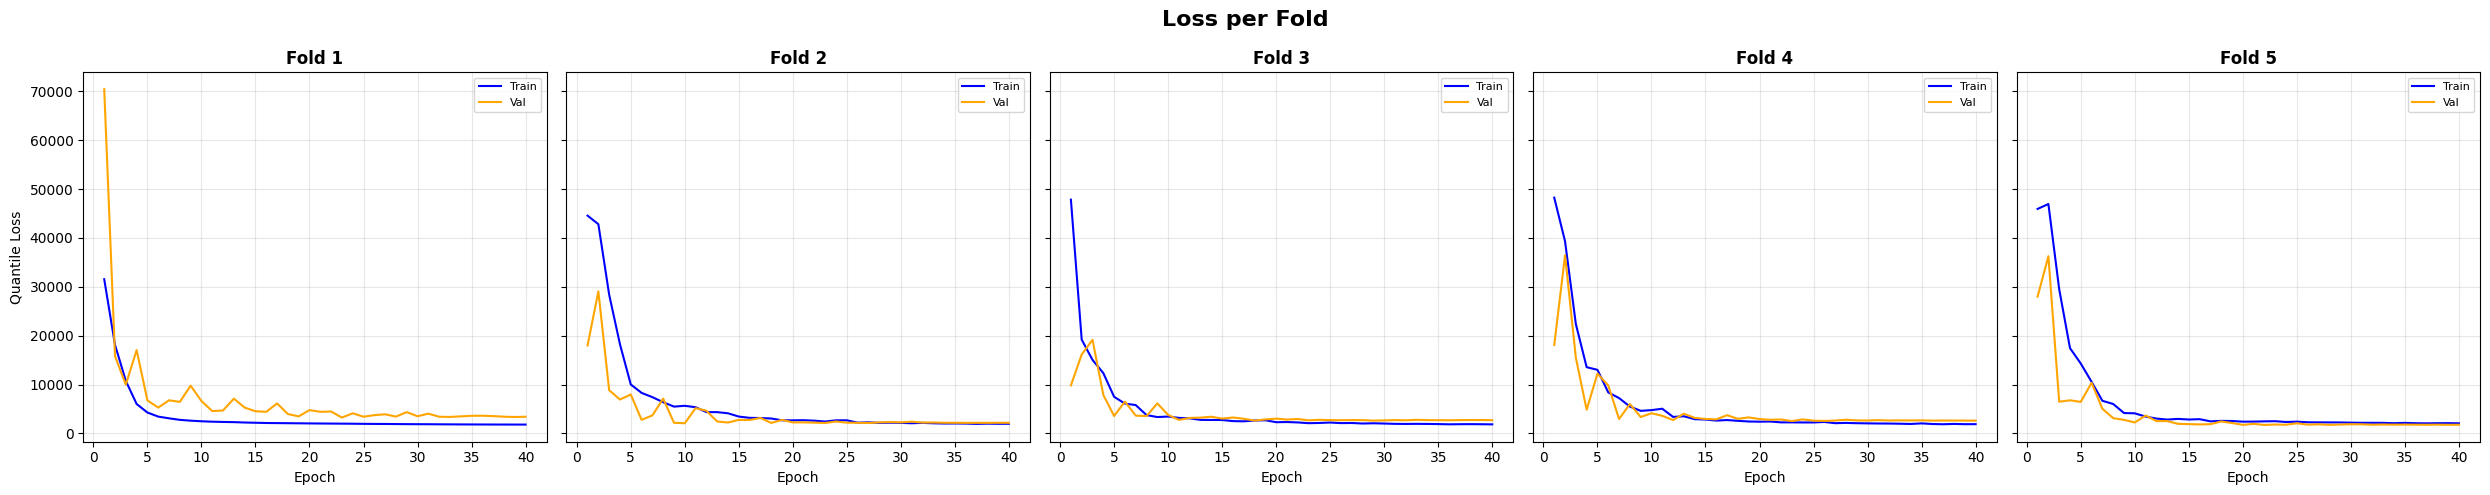

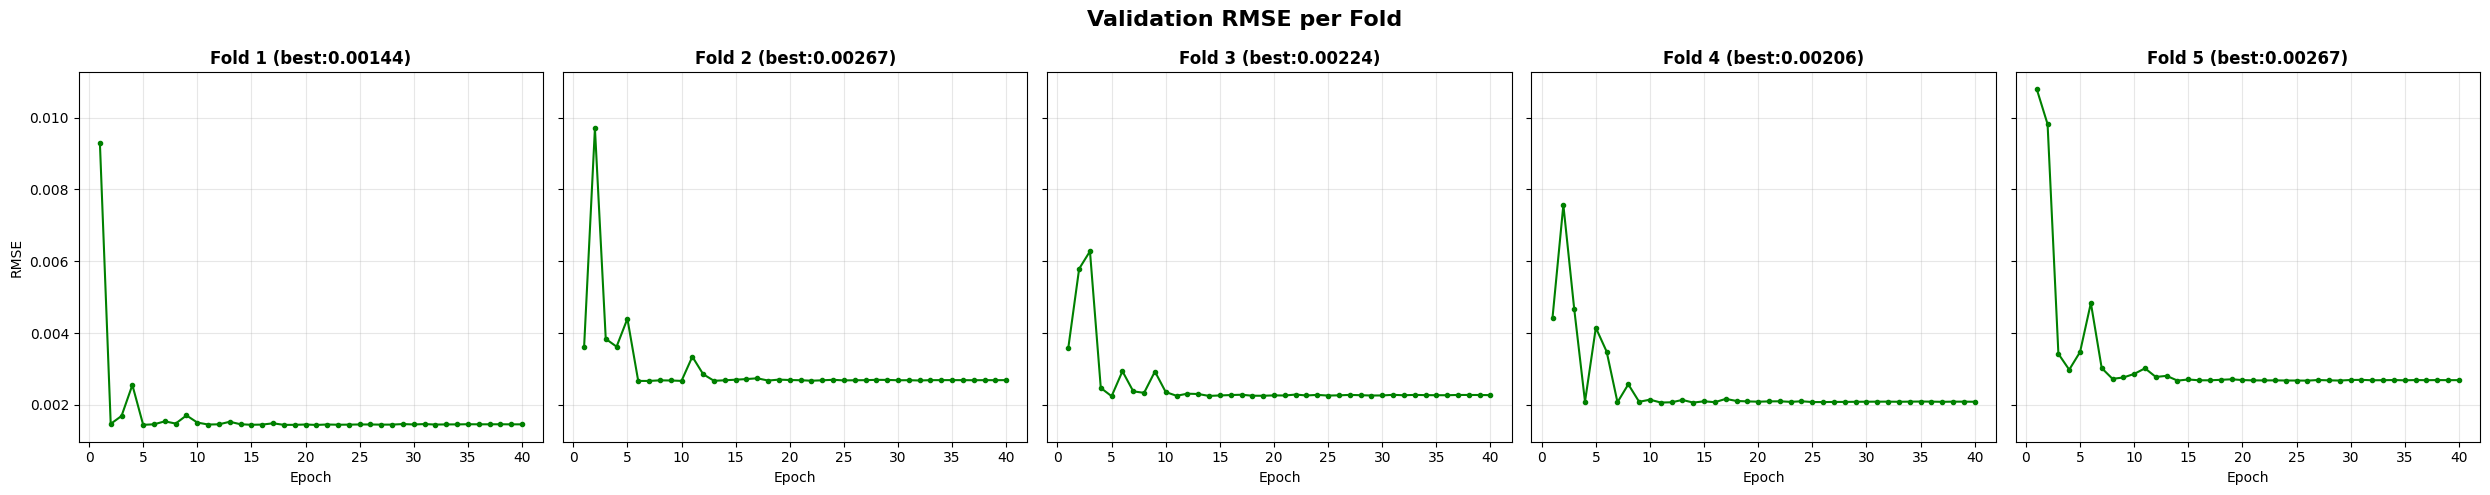

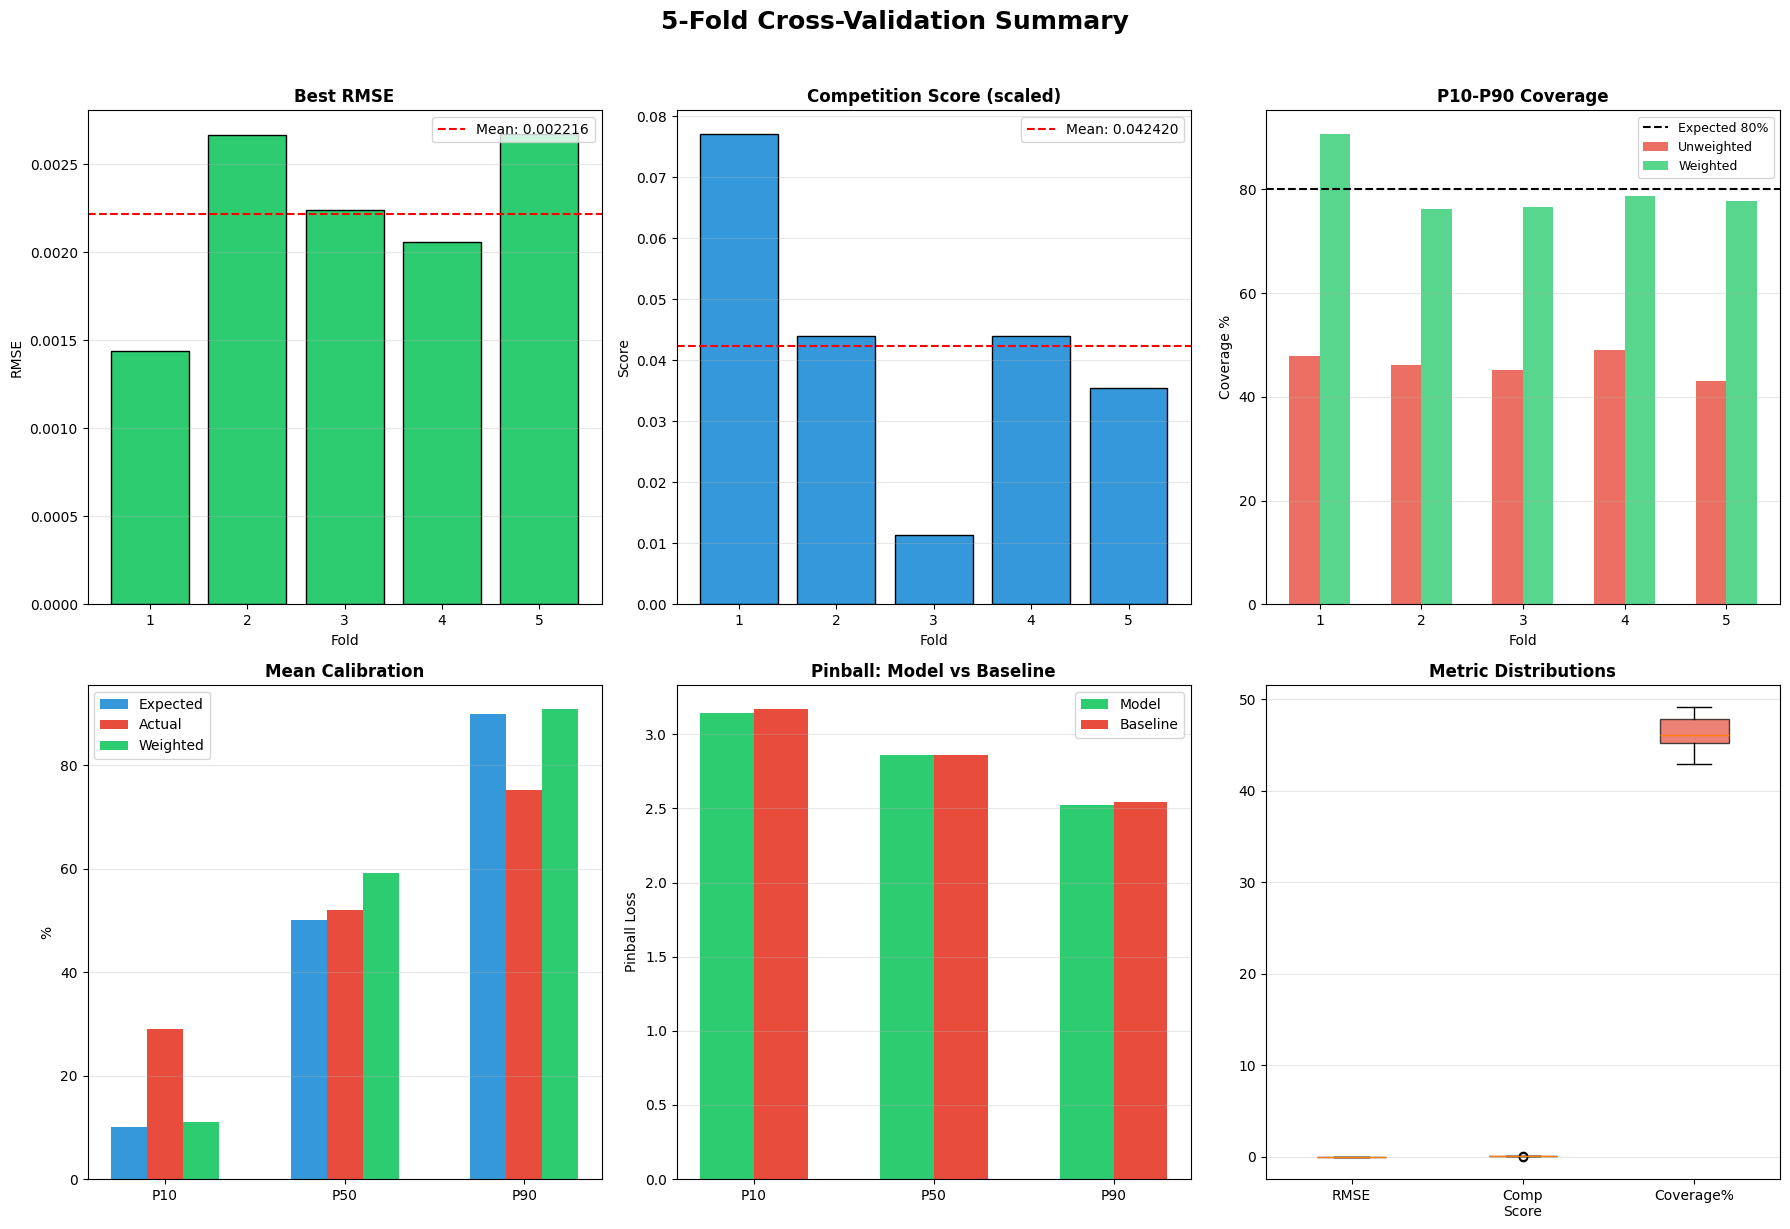

2026-04-14 09:26:36 | All plots saved to checkpoints_07_kfold
2026-04-14 09:26:36 | ============================================================
2026-04-14 09:26:36 | 5-FOLD CROSS-VALIDATION COMPLETE!
2026-04-14 09:26:36 | ============================================================


In [11]:
# (A) Loss curves per fold
fig, axes = plt.subplots(1, K_FOLDS, figsize=(5*K_FOLDS, 5), sharey=True)
for i, r in enumerate(all_fold_results):
    ax = axes[i]
    ep = range(1, len(r['train_losses'])+1)
    ax.plot(ep, r['train_losses'], label='Train', color='blue')
    ax.plot(ep, r['val_losses'], label='Val', color='orange')
    ax.set_title(f"Fold {r['fold']}", fontweight='bold')
    ax.set_xlabel('Epoch'); ax.grid(alpha=0.3); ax.legend(fontsize=8)
    if i == 0: ax.set_ylabel('Quantile Loss')
plt.suptitle('Loss per Fold', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"loss_per_fold.png", dpi=150, bbox_inches='tight'); plt.show()

# (B) RMSE curves per fold
fig, axes = plt.subplots(1, K_FOLDS, figsize=(5*K_FOLDS, 5), sharey=True)
for i, r in enumerate(all_fold_results):
    ax = axes[i]
    ax.plot(range(1, len(r['val_rmses'])+1), r['val_rmses'], marker='o', color='green', markersize=3)
    ax.set_title(f"Fold {r['fold']} (best:{r['best_rmse']:.5f})", fontweight='bold')
    ax.set_xlabel('Epoch'); ax.grid(alpha=0.3)
    if i == 0: ax.set_ylabel('RMSE')
plt.suptitle('Validation RMSE per Fold', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"rmse_per_fold.png", dpi=150, bbox_inches='tight'); plt.show()

# (C) Summary bar charts
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# RMSE
ax = axes[0,0]; rv = [r['best_rmse'] for r in all_fold_results]
ax.bar(range(1,K_FOLDS+1), rv, color='#2ecc71', edgecolor='black')
ax.axhline(np.mean(rv), color='red', linestyle='--', label=f'Mean: {np.mean(rv):.6f}')
ax.set_xlabel('Fold'); ax.set_ylabel('RMSE'); ax.set_title('Best RMSE', fontweight='bold'); ax.legend(); ax.grid(axis='y', alpha=0.3)

# Comp Score
ax = axes[0,1]; cv = [r['opt_comp_score'] for r in all_fold_results]
ax.bar(range(1,K_FOLDS+1), cv, color='#3498db', edgecolor='black')
ax.axhline(np.mean(cv), color='red', linestyle='--', label=f'Mean: {np.mean(cv):.6f}')
ax.set_xlabel('Fold'); ax.set_ylabel('Score'); ax.set_title('Competition Score (scaled)', fontweight='bold'); ax.legend(); ax.grid(axis='y', alpha=0.3)

# Coverage
ax = axes[0,2]
c1 = [r['coverage']*100 for r in all_fold_results]
c2 = [r['w_coverage']*100 for r in all_fold_results]
x = np.arange(1,K_FOLDS+1)
ax.bar(x-0.15, c1, 0.3, label='Unweighted', color='#e74c3c', alpha=0.8)
ax.bar(x+0.15, c2, 0.3, label='Weighted', color='#2ecc71', alpha=0.8)
ax.axhline(80, color='black', linestyle='--', label='Expected 80%')
ax.set_xlabel('Fold'); ax.set_ylabel('Coverage %'); ax.set_title('P10-P90 Coverage', fontweight='bold'); ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

# Calibration
ax = axes[1,0]
exp = [10,50,90]
act = [np.mean([r['cal_p10'] for r in all_fold_results])*100, np.mean([r['cal_p50'] for r in all_fold_results])*100, np.mean([r['cal_p90'] for r in all_fold_results])*100]
wgt = [np.mean([r['w_cal_p10'] for r in all_fold_results])*100, np.mean([r['w_cal_p50'] for r in all_fold_results])*100, np.mean([r['w_cal_p90'] for r in all_fold_results])*100]
xp = np.arange(3)
ax.bar(xp-0.2, exp, 0.2, label='Expected', color='#3498db')
ax.bar(xp, act, 0.2, label='Actual', color='#e74c3c')
ax.bar(xp+0.2, wgt, 0.2, label='Weighted', color='#2ecc71')
ax.set_xticks(xp); ax.set_xticklabels(['P10','P50','P90'])
ax.set_ylabel('%'); ax.set_title('Mean Calibration', fontweight='bold'); ax.legend(); ax.grid(axis='y', alpha=0.3)

# Pinball
ax = axes[1,1]
mpl = [np.mean([r['pl_10'] for r in all_fold_results]), np.mean([r['pl_50'] for r in all_fold_results]), np.mean([r['pl_90'] for r in all_fold_results])]
bpl = [np.mean([r['bl_10'] for r in all_fold_results]), np.mean([r['bl_50'] for r in all_fold_results]), np.mean([r['bl_90'] for r in all_fold_results])]
ax.bar(xp-0.15, mpl, 0.3, label='Model', color='#2ecc71')
ax.bar(xp+0.15, bpl, 0.3, label='Baseline', color='#e74c3c')
ax.set_xticks(xp); ax.set_xticklabels(['P10','P50','P90'])
ax.set_ylabel('Pinball Loss'); ax.set_title('Pinball: Model vs Baseline', fontweight='bold'); ax.legend(); ax.grid(axis='y', alpha=0.3)

# Box plot
ax = axes[1,2]
bp = ax.boxplot([rv, cv, c1], labels=['RMSE', 'Comp\nScore', 'Coverage%'], patch_artist=True, widths=0.4)
for patch, color in zip(bp['boxes'], ['#2ecc71','#3498db','#e74c3c']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_title('Metric Distributions', fontweight='bold'); ax.grid(axis='y', alpha=0.3)

plt.suptitle('5-Fold Cross-Validation Summary', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"cv_summary.png", dpi=150, bbox_inches='tight'); plt.show()

log.info("All plots saved to " + str(OUTPUT_DIR))
log.info("=" * 60)
log.info("5-FOLD CROSS-VALIDATION COMPLETE!")
log.info("=" * 60)